# Final Project: Geospatial Big Data Analysis

**submitted by:** Eliya Levin, 318163748

## Setup

### Libraries

In [3]:
# General
import time
import os

# Data handling
import numpy as np
import pandas as pd
import geopandas as gpd
import json

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial statistics
import libpysal
import sklearn

### Environment
The program can be run on different folders, however it assumes a `\data` folder exists in the same directory with all relevant data and an `\outputs` folder to save all outputs created during the analysis.

In [4]:
current_dir = os.getcwd() # directory path of the notebook
input_path = os.path.join(current_dir, r'data') # path to the input data folder
output_path = os.path.join(current_dir, r'outputs') # path to the output folder

## EDA: Exploratory Data Analysis and Data Cleaning

In [23]:
# Upload power plant csv file: Notice it's not a geographic layer yet
power_plants = pd.read_csv(input_path + r'\global_power_plant_database.csv')

In [24]:
# Inspect data types, columns and null-count
power_plants.info()

<class 'pandas.DataFrame'>
RangeIndex: 25648 entries, 0 to 25647
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   25648 non-null  str    
 1   country_long              25648 non-null  str    
 2   name                      25628 non-null  str    
 3   gppd_idnr                 25648 non-null  str    
 4   capacity_mw               25648 non-null  float64
 5   latitude                  25648 non-null  float64
 6   longitude                 25648 non-null  float64
 7   fuel1                     25648 non-null  str    
 8   fuel2                     1670 non-null   str    
 9   fuel3                     295 non-null    str    
 10  fuel4                     107 non-null    str    
 11  commissioning_year        13926 non-null  float64
 12  owner                     17148 non-null  str    
 13  source                    25648 non-null  str    
 14  url              

relevant columns:
* `capacity_mw` - capacity in megawatts. How much energy the plant can produce in a given time.
* `country` - country code, enables to aggregate by each country.
* `fuel1` - main fuel used in the plant.
* `commissioning_year` - year in which the plant started working.
* `owner` - company which owns the plant (total of 8300)
* `generation_gwh_{year}` - total amount of electricity produced by the plant in a given year, measured in gigawatt-hours.

In [ ]:
# Remove irrelevant columns for analysis
power_plants.drop(columns=['name', 'gppd_idnr', 'source', 'url', 'geolocation_source'], inplace=True)

In [28]:
# Describe base statistics for numeric columns
power_plants.describe().T

,count,mean,std,min,25%,50%,75%,max
capacity_mw,25648.0,157.662666,454.179790,1.0000,4.000000,14.800000,80.707500,8868.000000
latitude,25648.0,31.858471,25.129368,-77.8470,28.158925,40.745100,48.186950,71.292000
longitude,25648.0,-27.329513,67.322780,-171.7124,-81.919575,-34.863600,8.377625,177.483300
commissioning_year,13926.0,1994.051937,23.930358,1896.0000,1984.000000,2003.000000,2012.000000,2018.000000
year_of_capacity_data,16065.0,2016.035543,1.261272,2000.0000,2016.000000,2016.000000,2016.000000,2018.000000
generation_gwh_2013,56.0,2518.015893,7274.323147,10.0000,139.315000,439.000000,1356.750000,50834.000000
generation_gwh_2014,55.0,4033.036364,4743.669497,7.0000,637.500000,2196.000000,5818.500000,21615.000000
generation_gwh_2015,536.0,1411.243648,3719.310317,0.0000,26.155250,271.000000,1342.547500,59546.865000
generation_gwh_2016,8657.0,603.075345,2079.091735,-768.6200,3.331000,23.726200,217.900915,32377.477000
estimated_generation_gwh,24932.0,705.562610,2502.932203,0.0000,6.743264,34.755692,256.051411,57964.915966


In [21]:
power_plants.isnull().sum()

country                         0
country_long                    0
capacity_mw                     0
latitude                        0
longitude                       0
fuel1                           0
fuel2                       23978
fuel3                       25353
fuel4                       25541
commissioning_year          11722
owner                        8500
year_of_capacity_data        9583
generation_gwh_2013         25592
generation_gwh_2014         25593
generation_gwh_2015         25112
generation_gwh_2016         16991
estimated_generation_gwh      716
dtype: int64

In [22]:
power_plants['owner'].nunique()

8300

In [29]:
# Convert to GeoDataFrame using longitude and latitude columns.
# Note: CRS is defined as a geographical world Datum WGS84 (epsg=4326), as it is a world dataset.
power_plants = gpd.GeoDataFrame(
    power_plants,
    geometry=gpd.points_from_xy(
        power_plants.longitude,
        power_plants.latitude
    ),
    crs="EPSG:4326"
)

In [34]:
continents = gpd.read_file(input_path + r'\Continents.shp')

In [36]:
continents.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

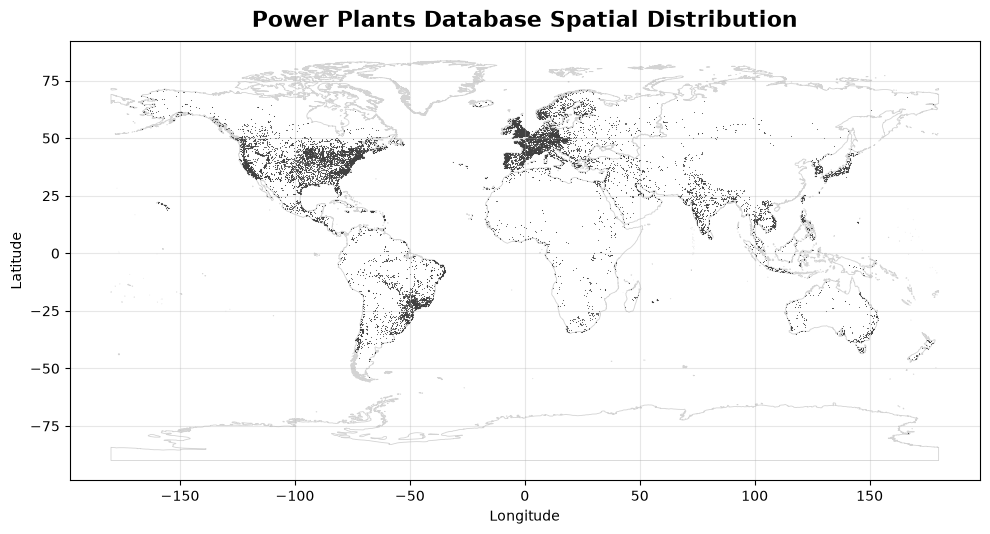

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
continents.plot(
    ax=ax,
    color='white',
    edgecolor='lightgrey',
    linewidth=0.6
)

power_plants.plot(
    ax=ax,
    markersize=0.4,
    color='black',
    edgecolor='grey',
    linewidth=0.1
)

ax.set_title('Power Plants Database Spatial Distribution', fontsize=16, fontweight='bold', pad=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Axes: >

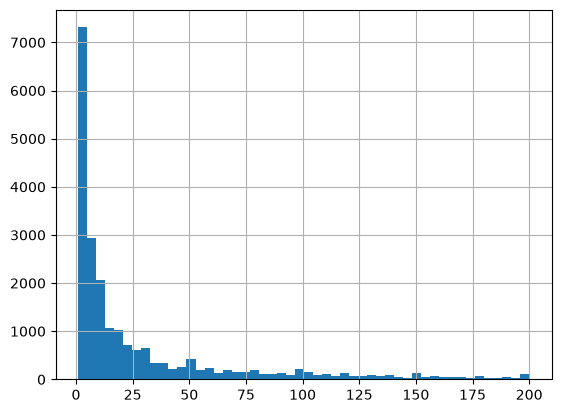

In [64]:
power_plants['capacity_mw'][power_plants['capacity_mw'] <= 200].hist(bins=50)

<Axes: >

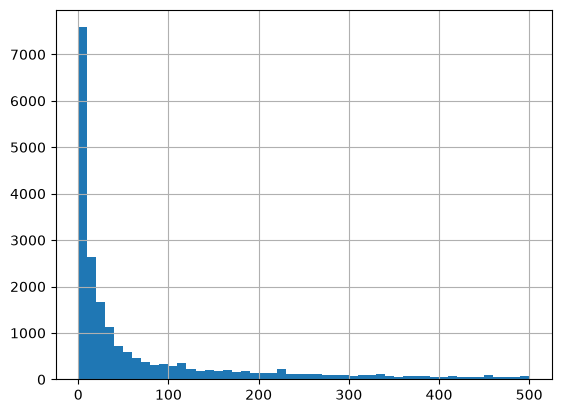

In [57]:
power_plants['estimated_generation_gwh'][power_plants['estimated_generation_gwh'] <= 500].hist(bins=50)

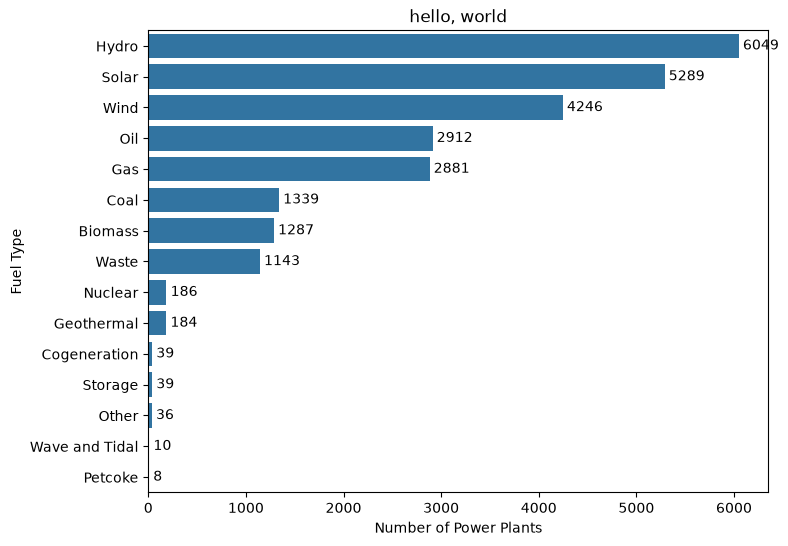

In [74]:
# order categories by count (descending)
order = power_plants['fuel1'].value_counts().index

# create plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(
    data=power_plants,
    y='fuel1',
    order=order,
    ax=ax
)

# add numbers at the end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlabel('Number of Power Plants')
plt.ylabel('Fuel Type')
plt.title('hello, world')
plt.show()

## Analysis